# AG-HYPOPT · Trial 15

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Fourteen trials. Best: **trial_13** `cvm_fwhm` **0.0733** (sw 0.1910). The six `cvm_fwhm` points span
0.0733-0.0798 over sw 0.18-0.23 (mean ~0.0771), all at or just under the KDE control (0.080328) - so the
family's edge is real but small (~0.003 on the mean) and within the basin the seed scatter (~0.004)
dominates the sw dependence. A caveat that still matters for the head-to-head: KDE has only been tested
at sw 0.2279 (0.0830) and its own control setting, never at the sw ~0.19 where `cvm_fwhm` is best, so a
KDE point in the basin would settle whether the margin is form or sw. No divergences. Phase `trials`
(14/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_15'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (14/5 trials)
ID |     ei | params
 1 | 2.9146 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2175970966049451}
 2 | 2.3175 | {"loss_family": "kde", "sigma_weight": 0.18945952639848865}
 3 | 2.2600 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.17395608303934523}
 4 | 2.8062 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2323504983994203}
 5 | 2.7605 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.23689181353261393}
 6 | 3.2268 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20749005248906027}
 7 | 2.5966 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.24200676583284153}
 8 | 2.6248 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.17727402673170958}
 9 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.7833538476638741}
10 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.36152748293074355}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI now fills with `cvm_fwhm` in the basin (candidates 6, 1, 4, 5, 7, 8, 3), which mainly asks for more
confirmations of an already-flat optimum. The one measurement that would still change the conclusion is a
**KDE point at the basin sw**: `cvm_fwhm` is best near sw ~0.19, but KDE has only been sampled at sw 0.2279
(0.0830). If KDE also drops to ~0.076 at sw 0.19, the `cvm_fwhm` edge is really a sw effect; if it stays
at ~0.080+, the edge is confirmed as the loss form.

Candidate 2 is exactly that test: `kde` at sw 0.1895 (ei 2.3175), right at the `cvm_fwhm` optimum. The
alternatives are more `cvm_fwhm` re-runs (lower information now) or the weak families at covered sw
values (candidates 9, 10).

I choose candidate 2.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'kde', 'sigma_weight': 0.18945952639848865}
Running  1nW Trans05 ... 

μ 9.39 -> 6.03 | γ 8.5 -> 4.58 | NLL 0.15


Running  1nW Trans20 ... 

μ 17.32 -> 25.64 | γ 8.5 -> 5.29 | NLL 0.42


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 66.84 | γ 14.1 -> 14.03 | NLL 0.54


Running 3nW Trans100 ... 

μ 175.71 -> 94.61 | γ 14.1 -> 13.73 | NLL 0.54



Total: 7.9 min


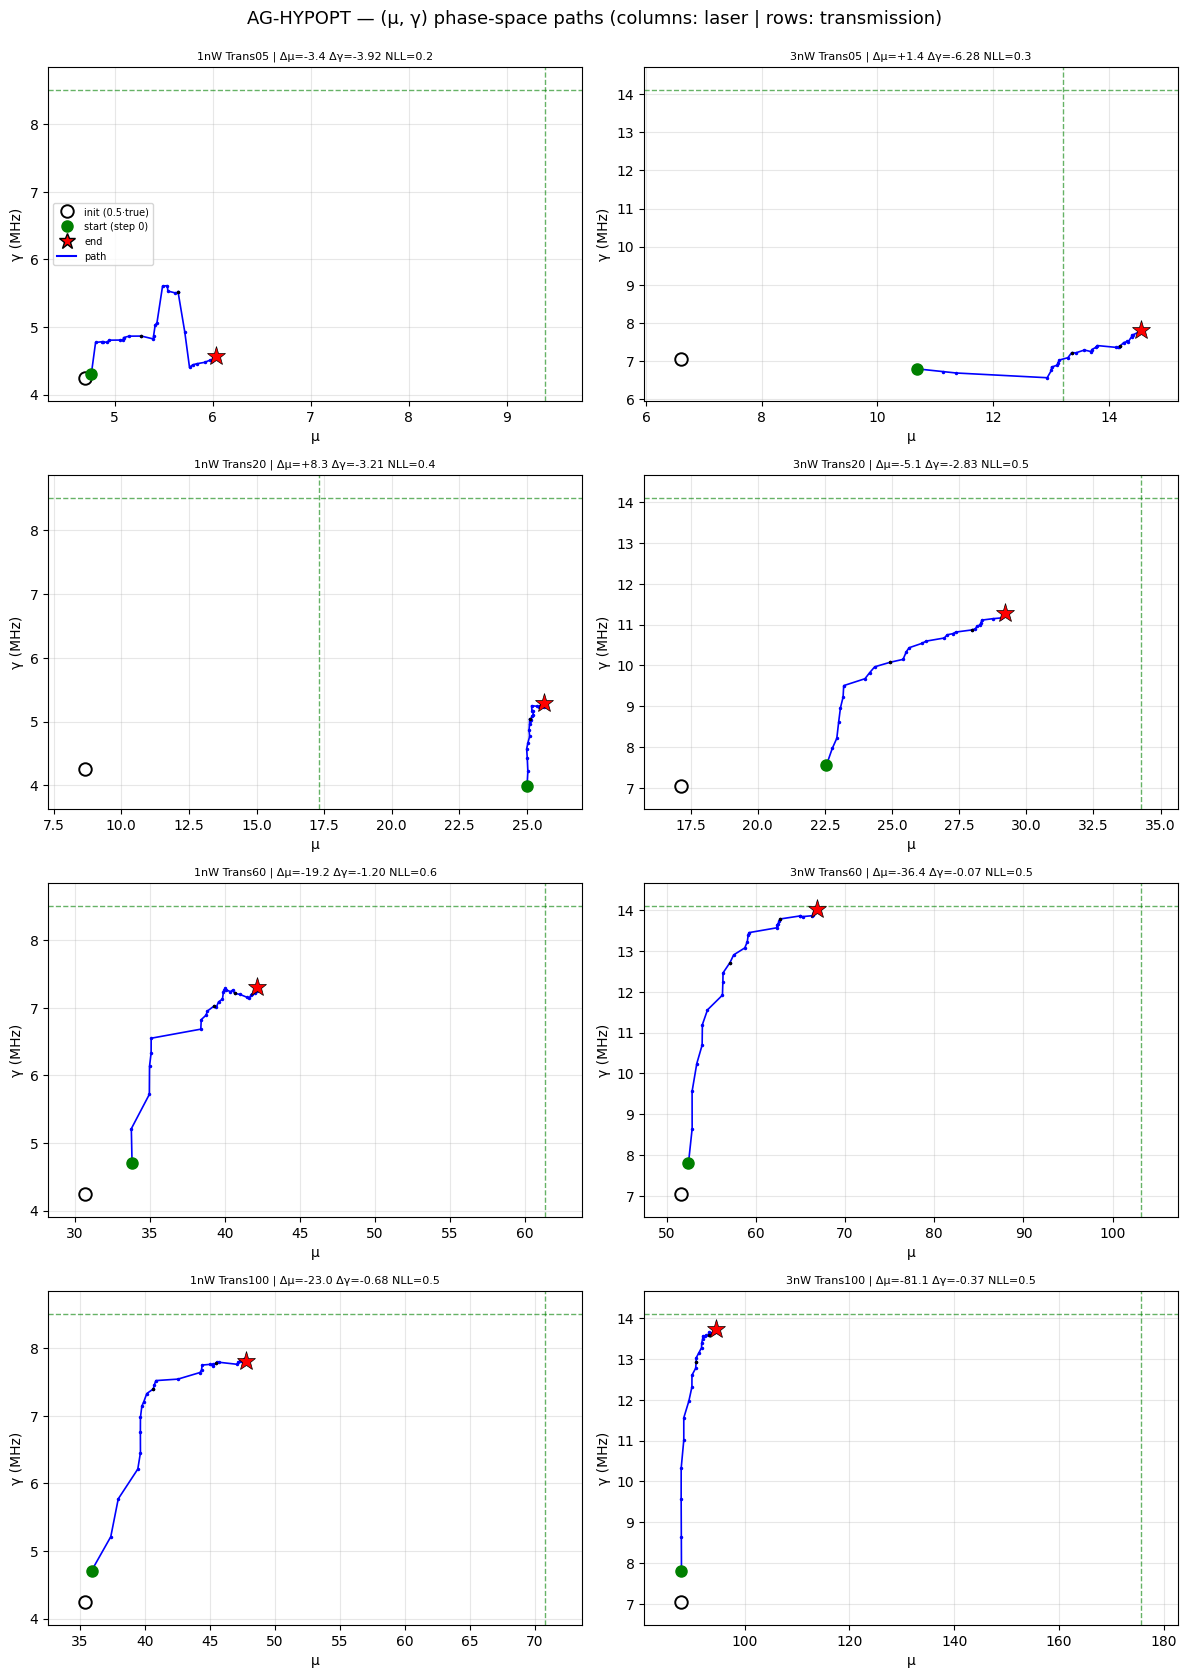

trial finished in 7.9 min
objective = 0.0866 ± 0.0212
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.03   -35.8 |     8.50    4.58   -46.2
1nW Trans20       17.32   25.64   +48.1 |     8.50    5.29   -37.8
1nW Trans60       61.37   42.17   -31.3 |     8.50    7.30   -14.1
1nW Trans100       70.82   47.82   -32.5 |     8.50    7.82    -8.1
3nW Trans05       13.20   14.56   +10.3 |    14.10    7.82   -44.6
3nW Trans20       34.28   29.21   -14.8 |    14.10   11.27   -20.0
3nW Trans60      103.20   66.84   -35.2 |    14.10   14.03    -0.5
3nW Trans100      175.71   94.61   -46.2 |    14.10   13.73    -2.6

weighted objective (T-graded, cap=1.0) = 0.0866 | diverged cells: 0
μ: RMSE 33.363 (rel 34.1%, bias -19.800) | γ: RMSE 3.066 (rel 27.9%, bias -2.320)


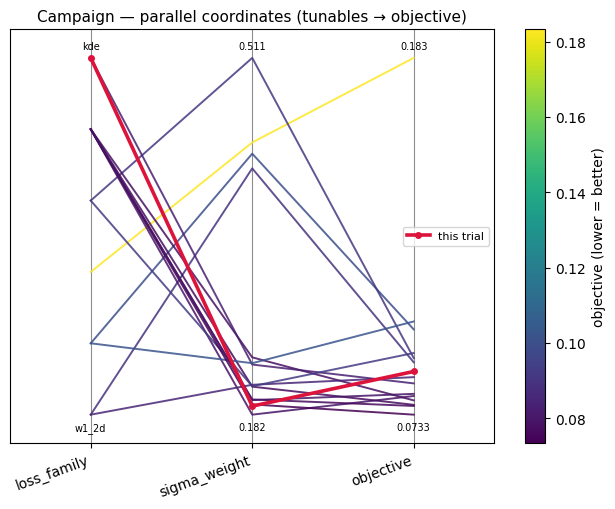

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'kde', sigma_weight: 0.1895}` (candidate 2). Trial time
7.9 min, objective **0.0866 +/- 0.0212**, **0 diverged cells**. This puts the KDE control square in the
`cvm_fwhm` basin (sw ~0.19) and it does **not** improve: KDE now reads control-setting 0.0803,
sw 0.2279 -> 0.0830, sw 0.1895 -> 0.0866. Its response to sw is flat (slightly worse away from the
control setting), while `cvm_fwhm` at these same sw values sits at 0.073-0.080.

**What this settles.** The head-to-head at matched sw is now measured on both sides: at sw ~0.19,
`cvm_fwhm` ~0.073-0.076 vs KDE 0.0866; at sw ~0.23, `cvm_fwhm` ~0.0777 vs KDE 0.0830. So the `cvm_fwhm`
advantage (~0.004-0.010 at matched sw) is a genuine **loss-form** effect, not a `sigma_weight` artifact.

**Per-cell behaviour.**

- 1nW Trans05: mu -35.8 %, gamma 8.5 -> 4.58 (-46.2 %).
- 1nW Trans20: mu +48.1 %, gamma -37.8 %.
- 1nW Trans60 / Trans100: mu -31.3 % / -32.5 %, gamma -14.1 % / -8.1 %.
- 3nW Trans05 / Trans20: mu +10.3 % / -14.8 %, gamma -44.6 % / -20.0 %.
- 3nW Trans60 / Trans100: mu -35.2 % / -46.2 %, gamma -0.5 % / -2.6 %.

**Aggregates.** mu: RMSE 33.36 (rel 34.1 %), bias -19.80; gamma: RMSE 3.07 (rel 27.9 %), bias -2.32 -
gamma clearly worse than `cvm_fwhm`'s 2.28-2.38.

**Summary:** The KDE control at sw 0.1895 gives objective 0.0866, no better than its own reference and
well behind `cvm_fwhm` at the same sw, confirming the campaign's winner is the Cramer-von Mises FWHM loss.
**Key insight:** At matched sw KDE is flat/immune to the low-sw region while `cvm_fwhm` improves, so the
~0.004-0.010 `cvm_fwhm` advantage is the loss form, not the `sigma_weight`.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'The KDE control at sigma_weight 0.1895 gives objective 0.0866, no better than its own reference and well behind cvm_fwhm at the same sw, confirming the campaign winner is the Cramer-von Mises FWHM loss.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'At matched sw KDE is flat/immune to the low-sw region while cvm_fwhm improves, so the ~0.004-0.010 cvm_fwhm advantage is the loss form, not the sigma_weight.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_15 | current best: trial_13


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_16.ipynb. Open it and follow its cells from the top.
